In [4]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [6]:
# 0K to 4K
t1 = 1E-12
t2 = 4.0


# (W - cm) per Kelvin 
# SC-086/50-NbTi-NbTi
# https://www.coax.co.jp/en/product/sc/086-50-nbti-nbti.html
g1 = 1E-12 # Linear extrapolation to zero in log-log scale as in krinner
g2 = 4.63E-6

# # (W - cm) per Kelvin 
# # SC-219/50-NbTi-NbTi
# # https://www.coax.co.jp/en/product/sc/219-50-nbti-nbti.html
# g1 = 1E-12 # Linear extrapolation to zero in log-log scale as in krinner
# g2 = 2.64E-5


# raicu
l_4K = 0.3155E2 # cm
l_Still = 0.2775E2 # cm
l_CP = 0.1965E2 # cm
l_MXC = 0.1965E2 # cm

In [7]:
t_data = np.array([t1, t2])
g_data = np.array([g1, g2])

log_t_data = np.log10(t_data)
log_g_data = np.log10(g_data)

coefficients = np.polyfit(log_t_data, log_g_data, 1)

def conductivity(x_temp):
    log_x_temp = np.log10(x_temp)
    log_y_pred = coefficients[0]*log_x_temp + coefficients[1]
    return 10**log_y_pred # (W -meter) per Kelvin 


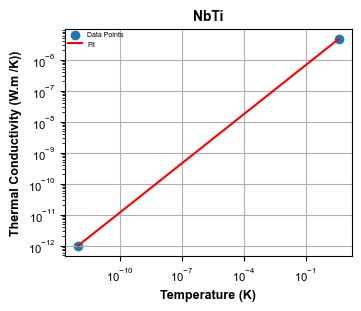

In [8]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.geomspace(1E-12, 4, num=100)
y_vals = conductivity(x_vals)
ax.scatter(t_data, g_data, label='Data Points')
ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("NbTi", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W.m /K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./nbti_k.png",dpi=600)
plt.show()

In [9]:
# Calculate the passive heat load (Watts) using integration
result, error = quad(conductivity, 1, 4) # Still
PHL_NbTi_Still = result / l_Still
print(f"{PHL_NbTi_Still=:.5e}")

result, error = quad(conductivity, 0.1, 1) # CP
PHL_NbTi_CP = result / l_CP
print(f"{PHL_NbTi_CP=:.5e}")

result, error = quad(conductivity, 0.01, 0.1) #MXC
PHL_NbTi_MXC = result / l_MXC
print(f"{PHL_NbTi_MXC=:.5e}")

PHL_NbTi_Still=3.84088e-07
PHL_NbTi_CP=7.18361e-08
PHL_NbTi_MXC=2.12527e-09
